# Module 12 - Programming Assignment

## General Directions

1. You must follow the Programming Requirements outlined on Canvas.
2. The Notebook should be cleanly and fully executed before submission.
3. You should change the name of this file to be your JHED id. For example, `jsmith299.ipynb` although Canvas will change it to something else...
4. You must follow the Programming Requirments for this course.

<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Important</strong>
    <p>
        You should always read the entire assignment before beginning your work, so that you know in advance what the requested output will be and can plan your implementation accordingly.
    </p>
</div>

<div style="color: white; background: #C83F49; margin:20px; padding: 20px;">
    <strong>Academic Integrity and Copyright</strong>
    <p>You are not permitted to consult outside sources (Stackoverflow, YouTube, ChatGPT, etc.) or use "code assistance" (Co-Pilot, etc) to complete this assignment. By submitting this assignment for grading, you certify that the submission is 100% your own work, based on course materials, group interactions, instructor guidance. You agree to comply by the requirements set forth in the Syllabus, including, by reference, the JHU KSAS/WSE Graduate Academic Misconduct Policy.</p>
    <p>Sharing this assignment either directly (e.g., email, github, homework site) or indirectly (e.g., ChatGPT, machine learning platform) is a violation of the copyright. Additionally, all such sharing is a violation the Graduate Academic Misconduct Policy (facilitating academic dishonesty is itself academic dishonesty), even after you graduate.</p>
    <p>If you have questions or if you're unsure about the policy, ask via Canvas Inbox. In this case, being forgiven is <strong>not</strong> easier than getting permission and ignorance is not an excuse.</p>
    <p>This assignment is copyright (&copy Johns Hopkins University &amp; Stephyn G. W. Butcher). All rights reserved.</p>
</div>

## k Nearest Neighbors and Model Evaluation

In this programming assignment you will use k Nearest Neighbors (kNN) to build a "model" that will estimate the compressive strength of various types of concrete. This assignment has several objectives:

1. Implement the kNN algorithm with k=9. Remember...the data + distance function is the model in kNN. In addition to asserts that unit test your code, you should "test drive" the model, showing output that a non-technical person could interpret.

2. You are going to compare the kNN model above against the baseline model described in the course notes (the mean of the training set's target variable). You should use 10 fold cross validation and Mean Squared Error (MSE):

$$MSE = \frac{1}{n}\sum^n_i (y_i - \hat{y}_i)^2$$

as the evaluation metric ("error"). Refer to the course notes for the format your output should take. Don't forget a discussion of the results.

3. use validation curves to tune a *hyperparameter* of the model. 
In this case, the hyperparameter is *k*, the number of neighbors. Don't forget a discussion of the results.

4. evaluate the *generalization error* of the new model.
Because you may have just created a new, better model, you need a sense of its generalization error, calculate that. Again, what would you like to see as output here? Refer to the course notes. Don't forget a discussion of the results. Did the new model do better than either model in Q2?

5. pick one of the "Choose Your Own Adventure" options.

Refer to the "course notes" for this module for most of this assignment.
Anytime you just need test/train split, use fold index 0 for the test set and the remainder as the training set.
Discuss any results.

## Load the Data

The function `parse_data` loads the data from the specified file and returns a List of Lists. The outer List is the data set and each element (List) is a specific observation. Each value of an observation is for a particular measurement. This is what we mean by "tidy" data.

The function also returns the *shuffled* data because the data might have been collected in a particular order that *might* bias training.

In [354]:
import random
from typing import List, Dict, Tuple, Callable

In [355]:
def parse_data(file_name: str) -> List[List]:
    data = []
    file = open(file_name, "r")
    for line in file:
        datum = [float(value) for value in line.rstrip().split(",")]
        data.append(datum)
    random.shuffle(data)
    return data

In [356]:
data = parse_data("concrete_compressive_strength.csv")

In [357]:
data[0]

[213.5, 0.0, 174.2, 154.6, 11.7, 1052.3, 775.5, 3.0, 17.37]

In [358]:
len(data)

1030

There are 1,030 observations and each observation has 8 measurements. The data dictionary for this data set tells us the definitions of the individual variables (columns/indices):

| Index | Variable | Definition |
|-------|----------|------------|
| 0     | cement   | kg in a cubic meter mixture |
| 1     | slag     | kg in a cubic meter mixture |
| 2     | ash      | kg in a cubic meter mixture |
| 3     | water    | kg in a cubic meter mixture |
| 4     | superplasticizer | kg in a cubic meter mixture |
| 5     | coarse aggregate | kg in a cubic meter mixture |
| 6     | fine aggregate | kg in a cubic meter mixture |
| 7     | age | days |
| 8     | concrete compressive strength | MPa |

The target ("y") variable is a Index 8, concrete compressive strength in (Mega?) [Pascals](https://en.wikipedia.org/wiki/Pascal_(unit)).

## Train/Test Splits - n folds

With n fold cross validation, we divide our data set into n subgroups called "folds" and then use those folds for training and testing. You pick n based on the size of your data set. If you have a small data set--100 observations--and you used n=10, each fold would only have 10 observations. That's probably too small. You want at least 30. At the other extreme, we generally don't use n > 10.

With 1,030 observations, n = 10 is fine so we will have 10 folds.
`create_folds` will take a list (xs) and split it into `n` equal folds with each fold containing one-tenth of the observations.

In [359]:
def create_folds(xs: List, n: int) -> List[List[List]]:
    k, m = divmod(len(xs), n)
    # be careful of generators...
    return list(xs[i * k + min(i, m):(i + 1) * k + min(i + 1, m)] for i in range(n))

In [360]:
folds = create_folds(data, 10)

In [361]:
len(folds)

10

We always use one of the n folds as a test set (and, sometimes, one of the folds as a *pruning* set but not for kNN), and the remaining folds as a training set.
We need a function that'll take our n folds and return the train and test sets:

In [362]:
def create_train_test(folds: List[List[List]], index: int) -> Tuple[List[List], List[List]]:
    training = []
    test = []
    for i, fold in enumerate(folds):
        if i == index:
            test = fold
        else:
            training = training + fold
    return training, test

We can test the function to give us a train and test datasets where the test set is the fold at index 0:

In [363]:
train, test = create_train_test(folds, 0)

In [364]:
len(train)

927

In [365]:
len(test)

103

## Answers

Answer the questions above in the space provided below, adding cells as you need to.
Put everything in the helper functions and document them.
Document everything (what you're doing and why).
If you're not sure what format the output should take, refer to the course notes and what they do for that particular topic/algorithm.

## Problem 1: kNN

Implement k Nearest Neighbors algorithm with k = 9. (Do not confuse the algorithm with evaluating the algorithm. We just want the algorithm here.)

<a id="processing"></a>
## processing

`processing` implements the regression portion of our kNN algorithm, and returns the mean target value of the k-nearest observations.  **Used By**: [knn](#knn)

* **nearest** list[tuple[float, list]]: the nearest neighbor observations from the kNN algorithm.

**returns** float: returns mean target value from the nearest observations.

In [366]:
def processing(nearest: list[tuple[float, list]]) -> float:
    return sum([i[1][-1] for i in nearest]) / len(nearest)

In [367]:
nearest = [(0, [0, 0, 0, 0, 0])]
assert processing(nearest) == 0.0
nearest = [(0, [0, 0, 0, 0, 0]), (1, [1, 1, 1, 1, 1])]
assert processing(nearest) == 0.5
nearest = [(0, [0, 0, 0, 0, 0]), (1, [1, 1, 1, 1, 1]), (2, [2, 2, 2, 2, 2])]
assert processing(nearest) == 1.0

<a id="distance"></a>
## distance

`distance` calculates the distance metric used in kNN. In this version, the squared Euclidean distance is used to save on computation cost. **Used By**: [knn](#knn)

* **example** list[float]: the neighboring observations.
* **query** list[float]: the reference observation.

**returns** float: returns the square of the Euclidean distance.

In [368]:
def distance(example: list[float], query: list[float]) -> float:
    return sum((example[i] - query[i]) ** 2 for i in range(len(query)))

In [369]:
example = [0, 0, 0, 0, 0]
query = [0, 0, 0, 0, 0]
assert distance(example, query) == 0.0
query = [1, 1, 1, 1, 1]
assert distance(example, query) == 5.0
query = [2, 2, 2, 2, 2]
assert distance(example, query) == 20.0

<a id="knn"></a>
## knn

`knn` runs regression k-Nearest Neighbors. It calculates the distance between the query and all other observations, sorts by ascending distance, and using the processing function returns the mean value of the target variable from the k-nearest distance observations.  **Uses**: [distance](#distance), [processing](#processing) **Used By**: [eval_knn_mse](#eval_knn_mse)

* **dataset** list[list[float]]: the input dataset for the kNN algorithm.
* **query** list[float]: observation to be used for prediction.
* **k** int: the number of nearest neighbors to retrieve for inference in kNN.

**returns** float: returns average target value from the k-nearest observations.

In [370]:
def knn(dataset: list[list[float]], query: list[float], k: int = 9) -> float:
    distances = []
    for example in dataset:
        distances.append((distance(example, query), example))
    nearest = sorted(distances, key=lambda x: x[0])
    nearest = nearest[:k]
    out = processing(nearest)
    return out

In [371]:
test_data = [[0, 0, 0, 0, 0], [1, 1, 1, 1, 5], [2, 2, 2, 2, 10]]
query = [0, 0, 0, 0]
assert knn(test_data, query, k=1) == 0.0
assert knn(test_data, query, k=2) == 2.5
assert knn(test_data, query, k=3) == 5.0

## Problem 2: Evaluation vs. The Mean

Using Mean Squared Error (MSE) as your evaluation metric, evaluate your implement above and the Null model, the mean. See the notes for the format of the output.

For this part of the assignment, the Programming Requirements are a bit difficult (although not impossible) to follow in terms of *testing*. If you can figure out how to test your code, that's best but if you can't, for this part of the assignment, that's ok.

<a id="eval_knn_mse"></a>
## eval_knn_mse

`eval_knn_mse` evaluates the MSE for kNN regression, using the input training and test sets. It uses the actual target value from each test observation and predicted target value from the training observations to sum the squared error before finally dividing by number of test instances to get MSE.  **Uses**: [knn](#knn), **Used By**: [cross_validate](#cross_validate)

* **train_dataset** list[list[float]]: the training dataset.
* **test_dataset** list[list[float]]: the test dataset (this could just be the training set again if we're looking at training error).
* **k** int: the number of nearest neighbors to retrieve for inference in kNN.
* **null** bool: a flag for whether to evaluate MSE against the null model, which sets the predicted value to the mean of the input training set.

**returns** float: returns MSE from the input training and test set.

In [372]:
def eval_knn_mse(train_dataset: list[list[float]], test_dataset: list[list[float]], k: int, null: bool=False) -> float:
    err = 0.0
    for obs in test_dataset:
        actual_target = obs[-1]
        if null:
            pred_target = sum([i[-1] for i in train_dataset]) / len(train_dataset)
        else:
            pred_target = knn(train_dataset, obs[:-1], k)
        err += (actual_target - pred_target)**2
    err = err / len(test_dataset)
    return err

In [373]:
train_data = [[0, 0, 0, 0, 0.0], [1, 1, 1, 1, 5.0], [2, 2, 2, 2, 10.0]]
assert eval_knn_mse(train_data, train_data, k=1) == 0.0
assert eval_knn_mse(train_data, train_data, k=2) == 6.25
assert abs(16.6666667 - eval_knn_mse(train_data, train_data, k=3)) < 0.01
test_data = [[0, 0, 0, 0, 0]]
assert eval_knn_mse(train_data, test_data, k=1) == 0.0
assert eval_knn_mse(train_data, test_data, k=2) == 6.25
assert eval_knn_mse(train_data, test_data, k=3) == 25.0
train_data = [[0, 0, 0, 0, 1.0], [1, 1, 1, 1, 2.0], [2, 2, 2, 2, 3.0]]
assert eval_knn_mse(train_data, test_data, k=1, null=True) == 4.0

<a id="cross_validate"></a>
## cross_validate

`cross_validate` runs cross validation for kNN, using a dataset and specified number of folds. It trains, and then evaluates error on both the training set and test set. The MSE is returned for each fold, and optionally can be printed to console. **Uses**: [eval_knn_mse](#eval_knn_mse), [create_folds](#create_folds)

* **observations** list[list[float]]: the input dataset for validation that will create folds and then train and evaluate for each split.
* **k** int: the number of nearest neighbors to retrieve for inference in kNN.
* **num_folds** int: the number of splits for cross validation in the dataset.
* **debug** bool: a flag to control whether the function prints to console.
* **null** bool: a flag to control whether to use the null model for fold validation.

**returns** tuple[list, list]: returns the list of training and test errors.

In [374]:
def cross_validate(observations: list[list[float]], k: int, num_folds: int, debug: bool=False, null: bool=False) -> tuple[list, list]:
    folded_data = create_folds(observations, num_folds)
    train_error = []
    test_error = []
    for i in range(len(folded_data)):
        train_folds = folded_data[:i] + folded_data[i+1:]
        training_set = sum(train_folds, [])
        test_set = folded_data[i]
        train_err = eval_knn_mse(training_set, training_set, k, null)
        test_err = eval_knn_mse(training_set, test_set, k, null)
        if debug:
            print(f"Fold {i + 1} MSE, train: {train_err:.4f} test: {test_err:.4f}")
        train_error.append(train_err)
        test_error.append(test_err)
    return train_error, test_error

In [375]:
mock_data = [[0, 0, 0, 0, 0.0], [0, 0, 0, 0, 0.0], [0, 0, 0, 0, 0.0]]
train_err, test_err = cross_validate(observations=mock_data, k=1, num_folds=3, debug=True)
assert train_err == [0.0, 0.0, 0.0]
assert test_err == [0.0, 0.0, 0.0]
mock_data = [[0, 0, 0, 0, 0.0], [1, 1, 1, 1, 5.0], [2, 2, 2, 2, 10.0]]
train_err, test_err = cross_validate(observations=mock_data, k=1, num_folds=3, debug=True)
assert train_err == [0.0, 0.0, 0.0]
assert test_err == [25.0, 25.0, 25.0]


Fold 1 MSE, train: 0.0000 test: 0.0000
Fold 2 MSE, train: 0.0000 test: 0.0000
Fold 3 MSE, train: 0.0000 test: 0.0000
Fold 1 MSE, train: 0.0000 test: 25.0000
Fold 2 MSE, train: 0.0000 test: 25.0000
Fold 3 MSE, train: 0.0000 test: 25.0000


In [376]:
data = parse_data("concrete_compressive_strength.csv")
train_err, test_err = cross_validate(observations=data, k=9, num_folds=10, debug=True, null=False)
null_train_err, null_test_err = cross_validate(observations=data, k=9, num_folds=10, debug=True, null=True)


Fold 1 MSE, train: 65.8241 test: 116.2780
Fold 2 MSE, train: 67.9826 test: 107.3983
Fold 3 MSE, train: 68.8401 test: 68.6694
Fold 4 MSE, train: 68.7798 test: 90.0416
Fold 5 MSE, train: 68.2363 test: 80.9580
Fold 6 MSE, train: 64.3385 test: 107.1349
Fold 7 MSE, train: 68.9081 test: 90.3200
Fold 8 MSE, train: 71.6618 test: 74.5542
Fold 9 MSE, train: 71.4038 test: 59.0201
Fold 10 MSE, train: 68.1335 test: 90.8994
Fold 1 MSE, train: 274.9029 test: 313.9907
Fold 2 MSE, train: 280.0249 test: 268.7430
Fold 3 MSE, train: 277.3098 test: 292.4119
Fold 4 MSE, train: 282.2730 test: 248.5867
Fold 5 MSE, train: 278.6531 test: 280.4978
Fold 6 MSE, train: 282.2064 test: 248.2542
Fold 7 MSE, train: 273.5946 test: 325.8758
Fold 8 MSE, train: 276.4223 test: 300.3655
Fold 9 MSE, train: 282.8687 test: 243.2324
Fold 10 MSE, train: 279.5081 test: 272.7021


The MSE using our kNN model with k=9 is substantially lower per fold than using the naive null model. This is to be expected when n >> k, because for regression the null model uses the mean of the entire training set which is likely underfitting, and kNN is using the mean of the local data points.

## Problem 3: Hyperparameter Tuning

Tune the value of k.

In [377]:
import matplotlib.pyplot as plt

In [378]:
mean_train_errs = []
mean_test_errs = []
start_k = 1
end_k = 20
for k in range(start_k,end_k + 1):
    train_err, test_err = cross_validate(observations=data, k=k, num_folds=10, debug=False, null=False)
    mean_train = sum(train_err) / len(train_err)
    mean_test = sum(test_err) / len(test_err)
    print(f"{k=}, {mean_train=}, {mean_test=}")
    mean_train_errs.append(mean_train)
    mean_test_errs.append(mean_test)


k=1, mean_train=3.4757908522114342, mean_test=75.07380368932039
k=2, mean_train=19.283911005933096, mean_test=75.5053704368932
k=3, mean_train=35.39645405609493, mean_test=72.63309220064723
k=4, mean_train=42.95853239751889, mean_test=74.52971979975727
k=5, mean_train=49.89780220884573, mean_test=77.79483083106796
k=6, mean_train=55.3184636854249, mean_test=81.97745289913702
k=7, mean_train=60.54509207582066, mean_test=87.01453546066972
k=8, mean_train=65.39309311117856, mean_test=89.1884180491505
k=9, mean_train=68.41085092079854, mean_test=88.52739030204961
k=10, mean_train=71.27732090226539, mean_test=90.93987331165049
k=11, mean_train=74.42601097265684, mean_test=93.09220885420848
k=12, mean_train=77.74018816859952, mean_test=94.65673766248652
k=13, mean_train=80.77442390992128, mean_test=96.05235720572185
k=14, mean_train=83.02757461104504, mean_test=96.54282884188629
k=15, mean_train=84.46822109778257, mean_test=99.20242872319311
k=16, mean_train=86.27253047671422, mean_test=101.

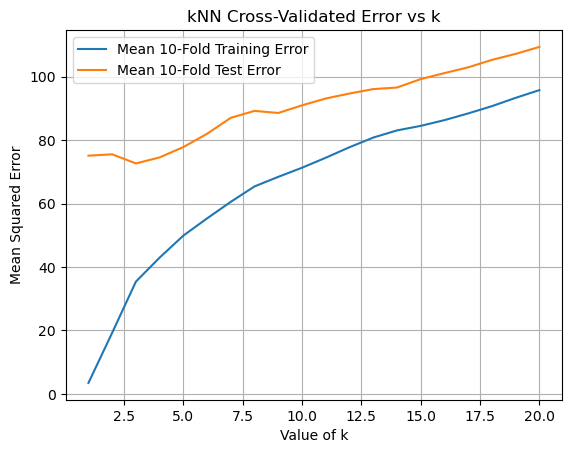

In [379]:
plt.figure()
plt.plot(range(start_k, end_k + 1), mean_train_errs, label="Mean 10-Fold Training Error")
plt.plot(range(start_k, end_k + 1), mean_test_errs, label="Mean 10-Fold Test Error")
plt.xlabel("Value of k")
plt.ylabel("Mean Squared Error")
plt.title("kNN Cross-Validated Error vs k")
plt.legend()
plt.grid()
plt.show()

For the hyperparameter tuning, I tested values of k from 1 to 20. The best region is between k=3 and k=4, with k=3 having the best overall test error.

## Problem 4: Generalization Error

Analyze and discuss the generalization error of your model with the value of k from Problem 3.

From question 3, the error was k=3, mean_train=35.39645405609493, mean_test=72.63309220064723, compared with mean_train=68.41085092079854, mean_test=88.52739030204961 for the original model. This means that for k=3, the model generalizes better than both the k=9 model and the null model.

## Problem 5: Choose your own adventure

You have two options for the next part:

1. You can implement mean normalization (also called "z-score standardization") of the *features*; **do not** normalize the target, y. See if this improves the generalization error of your model (middle).

2. You can implement *learning curves* to see if more data would likely improve your model (easiest).


In [382]:
data = parse_data("concrete_compressive_strength.csv")
data_size = []
train_err = []
test_err = []
for i in range(100, 1100, 100):
    dataset = data[:i]
    n = len(dataset)
    train, test = cross_validate(observations=dataset, k=3, num_folds=10, debug=False, null=False)
    mean_train = sum(train) / len(train)
    mean_test = sum(test) / len(test)
    print(f"{n=}, {mean_train=}, {mean_test=}")
    data_size.append(n)
    train_err.append(mean_train)
    test_err.append(mean_test)


n=100, mean_train=89.0079285925926, mean_test=197.57454022222225
n=200, mean_train=62.83588552469134, mean_test=128.7608582777778
n=300, mean_train=49.89868080246912, mean_test=110.51567996296299
n=400, mean_train=51.01852683333334, mean_test=112.35751300000001
n=500, mean_train=46.89826897530861, mean_test=103.49176326666668
n=600, mean_train=45.75166979835391, mean_test=97.6166723703704
n=700, mean_train=42.23839417107583, mean_test=97.28431974603174
n=800, mean_train=40.08705258024692, mean_test=88.86809358333333
n=900, mean_train=36.59951517009602, mean_test=81.38300883950618
n=1000, mean_train=36.047965611111124, mean_test=76.65173776666666


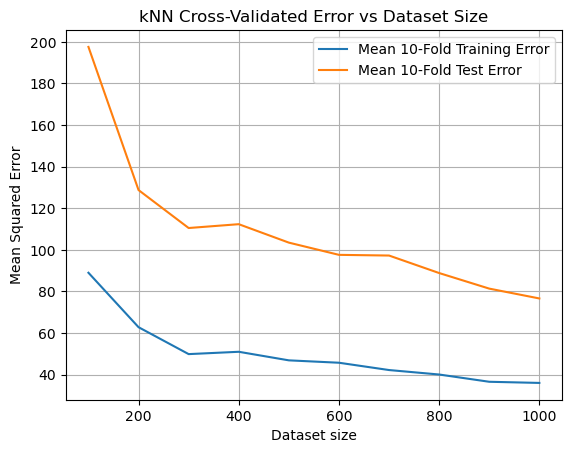

In [383]:
plt.figure()
plt.plot(data_size, train_err, label="Mean 10-Fold Training Error")
plt.plot(data_size, test_err, label="Mean 10-Fold Test Error")
plt.xlabel("Dataset size")
plt.ylabel("Mean Squared Error")
plt.title("kNN Cross-Validated Error vs Dataset Size")
plt.legend()
plt.grid()
plt.show()

I chose option 2. I reviewed the model error using k=3 for the test and training sets in 100 observation increments from 100 to close to the original dataset size. From the plot, we can see that the error steadily decreases as we add more datapoints. From the learning curves, it looks like the benefits from adding more data are beginning to diminish, but I wouldn't say they've hit a plateau yet with the dataset we're using in this exercise.

## Before You Submit...

1. Did you provide output exactly as requested?
2. Did you re-execute the entire notebook? ("Restart Kernel and Rull All Cells...")
3. If you did not complete the assignment or had difficulty please explain what gave you the most difficulty in the Markdown cell below.
4. Did you change the name of the file to `jhed_id.ipynb`?

Do not submit any other files.